
=== Scheduler Comparison Table ===
                  Total Carbon (kg CO2)  Max Temperature (C)  \
Carbon-only                    31046.55                 23.1   
Thermal-only                   31046.55                 23.1   
Reliability-only               31046.55                 23.1   
Integrated                     31046.55                 23.1   

                  Total Reliability Penalty  
Carbon-only                          6203.0  
Thermal-only                         6203.0  
Reliability-only                     6203.0  
Integrated                           6203.0  


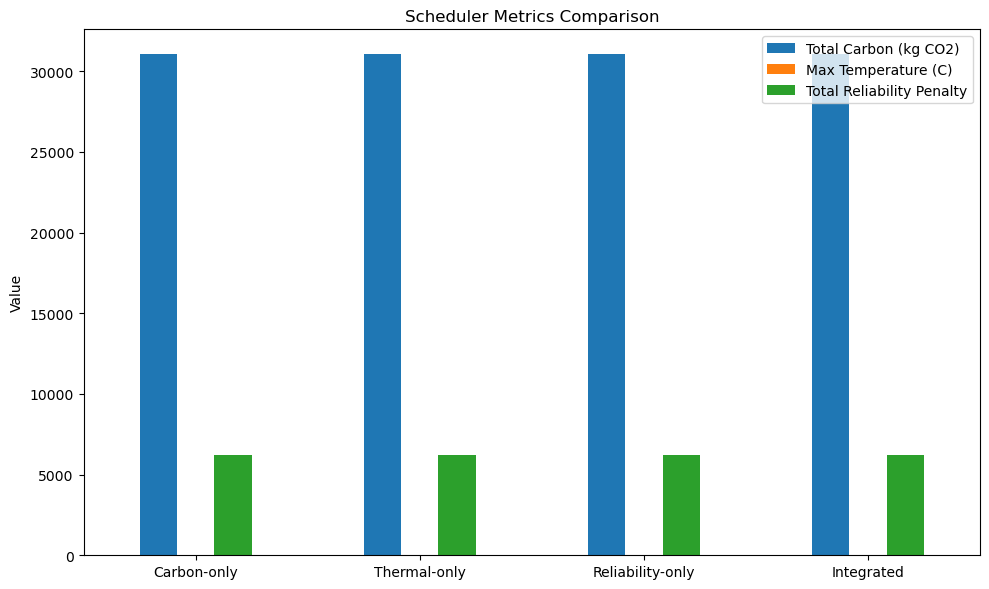

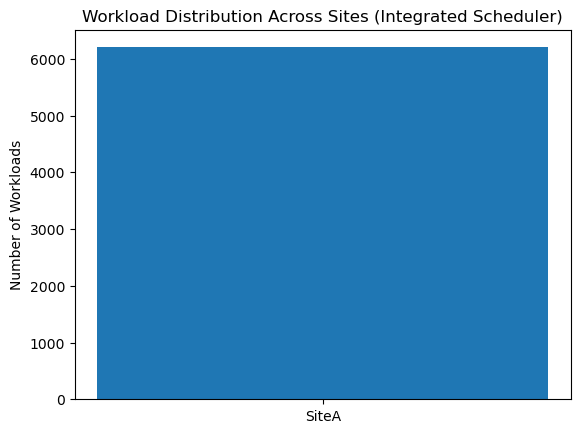

In [7]:
# ==============================
# Carbon-Thermal-Reliability-Aware Scheduler
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
T_MAX = 80            # Max safe temperature (Celsius)
ALPHA = 0.8           # Thermal model factor
BETA = 0.05           # CPU contribution to temp
GAMMA = 0.1           # Ambient contribution
KAPPA = 0.05          # Reliability penalty factor
LAMBDA_CARBON = 0.5
LAMBDA_THERMAL = 0.3
LAMBDA_RELIABILITY = 0.2

SITES = ["SiteA", "SiteB", "SiteC"]
CARBON_MEAN = [450, 500, 550]   # synthetic mean carbon per site gCO2/kWh
CARBON_STD = [20, 25, 30]       # synthetic variation

# -----------------------------
# LOAD WORKLOAD
# -----------------------------
workload_file = "alibaba_sample.csv"  # replace with your CSV path
df = pd.read_csv(workload_file)

# Convert scheduled_time to datetime
df['scheduled_time'] = pd.to_datetime(df['scheduled_time'], errors='coerce')
df = df.dropna(subset=['scheduled_time'])
df['time'] = df['scheduled_time'].astype(np.int64) // 10**9

# CPU in cores
df['cpu'] = df['cpu_milli'] / 1000

# Select relevant columns
workloads = df[['time', 'name', 'cpu']].rename(columns={'name':'workload_id'})
workloads = workloads.sort_values('time')

# -----------------------------
# SYNTHETIC TIME-VARYING CARBON PER SITE
# -----------------------------
time_points = sorted(workloads['time'].unique())
carbon_profile = {}
for i, site in enumerate(SITES):
    np.random.seed(i)
    carbon_profile[site] = np.random.normal(CARBON_MEAN[i], CARBON_STD[i], len(time_points))
    # Ensure no negative values
    carbon_profile[site] = np.clip(carbon_profile[site], 100, 1000)

# Map time to index for carbon lookup
time_index_map = {t: idx for idx, t in enumerate(time_points)}

# -----------------------------
# MULTI-OBJECTIVE SCHEDULER
# -----------------------------
def run_scheduler_multiobjective(workloads, sites, w_carbon=LAMBDA_CARBON, 
                                 w_thermal=LAMBDA_THERMAL, w_reliability=LAMBDA_RELIABILITY):
    site_temps = {s: 25.0 for s in sites}
    assignment = {}
    total_carbon = 0
    max_temp = 0
    total_reliability_penalty = 0

    for t in time_points:
        w_t = workloads[workloads['time']==t]
        for _, w in w_t.iterrows():
            best_score = float('inf')
            best_site = None
            for s in sites:
                # thermal model
                temp_next = ALPHA*site_temps[s] + BETA*w['cpu'] + GAMMA*25
                thermal_penalty = max(0, temp_next - T_MAX)
                reliability_penalty = np.exp(KAPPA * thermal_penalty)
                
                # time-varying carbon for this site
                idx = time_index_map[t]
                carbon_cost = w['cpu'] * carbon_profile[s][idx] / 1000  # kWh
                
                # composite score
                score = w_carbon*carbon_cost + w_thermal*thermal_penalty + w_reliability*reliability_penalty
                
                if score < best_score:
                    best_score = score
                    best_site = s
                    best_temp_next = temp_next

            # assign workload
            assignment[(w['workload_id'], t)] = best_site
            site_temps[best_site] = best_temp_next

            # metrics update
            total_carbon += carbon_cost
            max_temp = max(max_temp, best_temp_next)
            total_reliability_penalty += reliability_penalty

    metrics = {
        "Total Carbon (kg CO2)": total_carbon,
        "Max Temperature (C)": max_temp,
        "Total Reliability Penalty": total_reliability_penalty
    }
    return assignment, metrics

# -----------------------------
# RUN DIFFERENT WEIGHT SETTINGS
# -----------------------------
# 1. Carbon only
_, metrics_carbon = run_scheduler_multiobjective(workloads, SITES, w_carbon=1.0, w_thermal=0.0, w_reliability=0.0)
# 2. Thermal only
_, metrics_thermal = run_scheduler_multiobjective(workloads, SITES, w_carbon=0.0, w_thermal=1.0, w_reliability=0.0)
# 3. Reliability only
_, metrics_reliability = run_scheduler_multiobjective(workloads, SITES, w_carbon=0.0, w_thermal=0.0, w_reliability=1.0)
# 4. Integrated (all objectives)
assignment_integrated, metrics_integrated = run_scheduler_multiobjective(workloads, SITES)

# -----------------------------
# CREATE COMPARISON TABLE
# -----------------------------
results = {
    "Carbon-only": metrics_carbon,
    "Thermal-only": metrics_thermal,
    "Reliability-only": metrics_reliability,
    "Integrated": metrics_integrated
}
df_results = pd.DataFrame(results).T.round(2)
print("\n=== Scheduler Comparison Table ===")
print(df_results)

# -----------------------------
# PLOT COMPARISON
# -----------------------------
df_results.plot(kind='bar', figsize=(10,6))
plt.title("Scheduler Metrics Comparison")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -----------------------------
# WORKLOAD DISTRIBUTION (Integrated Scheduler)
# -----------------------------
workload_counts = pd.Series(list(assignment_integrated.values())).value_counts()
plt.bar(workload_counts.index, workload_counts.values)
plt.title("Workload Distribution Across Sites (Integrated Scheduler)")
plt.ylabel("Number of Workloads")
plt.show()